In [4]:
import json, re
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 90)

In [5]:
def load_profile(path):
    """Load a trtexec --exportProfile JSON. Skips the {"count":N} header."""
    with open(path) as f:
        raw = json.load(f)
    count = next((e["count"] for e in raw if "count" in e), None)
    entries = [e for e in raw if "name" in e]
    df = pd.DataFrame(entries)[["name","timeMs","averageMs","medianMs","percentage"]]
    for c in ["timeMs","averageMs","medianMs","percentage"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    print(f"{Path(path).name}: {len(df)} kernels (iterations={count})")
    return df

In [9]:
# look at the start and end of the FP16 file
with open(f"{BASE}/fp16_per_kernel_profile.json") as f:
    content = f.read()

print("File size:", len(content), "chars")
print("\n--- FIRST 200 chars ---")
print(repr(content[:200]))
print("\n--- LAST 200 chars ---")
print(repr(content[-200:]))

File size: 44464 chars

--- FIRST 200 chars ---
'[\n  { "count" : 3267 }\n, { "name" : "Reformatting CopyNode for Input Tensor 0 to /model.0/conv/Conv", "timeMs" : 103.298, "averageMs" : 0.0316186, "medianMs" : 0.03136, "percentage" : 1.93641 }\n, { "n'

--- LAST 200 chars ---
' }\n, { "name" : "__myl_CastReshReshGathCastReplDivNeqXorLtAndAddSeleSubReshCastGathConcCast_myl215_5", "timeMs" : 18.7836, "averageMs" : 0.00574951, "medianMs" : 0.005728, "percentage" : 0.352116 }\n]\n'


In [8]:
BASE = "/workspace/Per_kernel_json_file"
df_qat  = load_profile(f"{BASE}/qat_batch32_per_kernel_profile.json")
df_ptq  = load_profile(f"{BASE}/ptq_int8_per_kernel_profile.json")
df_fp16 = load_profile(f"{BASE}/fp16_per_kernel_profile.json")

df_qat["engine"]="QAT"; df_ptq["engine"]="PTQ"; df_fp16["engine"]="FP16"

qat_batch32_per_kernel_profile.json: 245 kernels (iterations=3198)
ptq_int8_per_kernel_profile.json: 189 kernels (iterations=3294)
fp16_per_kernel_profile.json: 231 kernels (iterations=3267)


In [10]:
QAT_PATH  = "/workspace/Per_kernel_json_file/qat_batch32_per_kernel_profile.json"
PTQ_PATH  = "/workspace/Per_kernel_json_file/ptq_int8_per_kernel_profile.json"
FP16_PATH = "/workspace/Per_kernel_json_file/fp16_per_kernel_profile.json"

df_qat  = load_profile(QAT_PATH)    # expect 245 kernels
df_ptq  = load_profile(PTQ_PATH)    # expect 189 kernels
df_fp16 = load_profile(FP16_PATH)   # expect 231 kernels  (same-arch, NO Q/DQ baseline)
df_qat.head(10)

qat_batch32_per_kernel_profile.json: 245 kernels (iterations=3198)
ptq_int8_per_kernel_profile.json: 189 kernels (iterations=3294)
fp16_per_kernel_profile.json: 231 kernels (iterations=3267)


,name,timeMs,averageMs,medianMs,percentage
0,__myl_MulMinMaxRounCast_myl0_0,24.6833,0.007718,0.007680,0.410286
1,model.0.conv.weight + /model.0/conv/weight_quantizer/QuantizeLinear + /model.0/conv/Co...,53.4611,0.016717,0.016640,0.888631
2,model.1.conv.weight + /model.1/conv/weight_quantizer/QuantizeLinear + /model.1/conv/Co...,40.2967,0.012601,0.012576,0.669812
3,model.2.cv1.conv.weight + /model.2/cv1/conv/weight_quantizer/QuantizeLinear + /model.2...,37.5717,0.011749,0.011680,0.624517
4,"PWN(/model.2/cv1/act/Sigmoid, /model.2/cv1/act/Mul)",24.3234,0.007606,0.007584,0.404304
5,__myl_MulMinMaxRounCastReplConcReshTran_myl5_0,25.7250,0.008044,0.008032,0.427601
6,model.2.m.0.cv1.conv.weight + /model.2/m.0/cv1/conv/weight_quantizer/QuantizeLinear + ...,38.2750,0.011968,0.011904,0.636208
7,model.2.m.0.cv2.conv.weight + /model.2/m.0/cv2/conv/weight_quantizer/QuantizeLinear + ...,41.7801,0.013064,0.013056,0.694470
8,__myl_MulMinMaxRounCast_myl8_0,21.4347,0.006703,0.006656,0.356288
9,"PWN(PWN(/model.2/m.0/cv2/act/Sigmoid, /model.2/m.0/cv2/act/Mul), /model.2/m.0/Add)",24.2405,0.007580,0.007552,0.402926


In [11]:
def kind(name):
    n = name.lower()
    if "attn" in n or "matmul" in n or "/qkv/" in n: return "attention"
    if "pwn" in n and "sigmoid" in n:
        return "conv+SiLU (fused)" if "conv" in n else "SiLU standalone"
    if "mulminmaxroun" in n: return "Q/DQ"
    if "conv.weight" in n or "/conv/" in n: return "conv only"
    if "reformat" in n or "repl" in n or "copy" in n: return "reformat"
    if "topk" in n: return "NMS/TopK"
    if "maxpool" in n: return "maxpool"
    if "resize" in n: return "resize"
    return "other"

def layer_key(name):
    """model.N group; extra kernels get typed keys."""
    m = re.search(r"model[./](\d+)", name)
    if m: return f"model.{m.group(1)}"
    n = name.lower()
    if "pwn" in n and "sigmoid" in n: return "SiLU_extra"
    if "mulminmaxroun" in n: return "Q/DQ_extra"
    if "topk" in n: return "NMS_extra"
    return "other_extra"

for df in (df_qat, df_ptq, df_fp16):
    df["kind"] = df["name"].apply(kind)
    df["layer_key"] = df["name"].apply(layer_key)

In [12]:
def cat_agg(df, tag):
    return df.groupby("kind")["averageMs"].agg(**{f"ms_{tag}":"sum", f"n_{tag}":"size"})

op = (cat_agg(df_qat,"QAT")
      .join(cat_agg(df_ptq,"PTQ"), how="outer")
      .join(cat_agg(df_fp16,"FP16"), how="outer").fillna(0))
op["Δms(QAT-PTQ)"]  = op["ms_QAT"] - op["ms_PTQ"]
op["Δms(QAT-FP16)"] = op["ms_QAT"] - op["ms_FP16"]
op = op.sort_values("ms_QAT", ascending=False)
print("=== OP-CATEGORY COMPARISON (all three engines) ===")
op.round(4)

=== OP-CATEGORY COMPARISON (all three engines) ===


,ms_QAT,n_QAT,ms_PTQ,n_PTQ,ms_FP16,n_FP16,Δms(QAT-PTQ),Δms(QAT-FP16)
kind,,,,,,,,
conv+SiLU (fused),0.4983,53,0.6968,74.0,0.6595,83.0,-0.1984,-0.1612
conv only,0.3742,42,0.1929,21.0,0.2658,32.0,0.1813,0.1084
Q/DQ,0.2915,48,0.0000,0.0,0.0000,0.0,0.2915,0.2915
SiLU standalone,0.2382,36,0.1178,17.0,0.1648,38.0,0.1204,0.0734
other,0.1727,26,0.0948,12.0,0.1389,20.0,0.0779,0.0338
attention,0.1128,16,0.2003,28.0,0.1160,20.0,-0.0875,-0.0032
reformat,0.1065,17,0.1918,30.0,0.2078,31.0,-0.0853,-0.1013
NMS/TopK,0.0447,2,0.0713,2.0,0.0443,2.0,-0.0265,0.0004
maxpool,0.0283,3,0.0283,3.0,0.0237,3.0,0.0000,0.0046


In [13]:
def per_layer(df_a, df_b, a="QAT", b="PTQ"):
    ga = df_a.groupby("layer_key")["averageMs"].agg(**{f"{a.lower()}_ms":"sum", f"{a.lower()}_n":"size"})
    gb = df_b.groupby("layer_key")["averageMs"].agg(**{f"{b.lower()}_ms":"sum", f"{b.lower()}_n":"size"})
    common = ga.join(gb, how="inner")
    ac, bc = f"{a.lower()}_ms", f"{b.lower()}_ms"
    common["Δms"] = common[ac] - common[bc]
    common["Δpct"] = (common["Δms"]/common[bc]*100).round(1)
    common[f"{a.lower()}_share%"] = (common[ac]/common[ac].sum()*100).round(1)
    common["extra_share%"] = (common["Δms"]/common["Δms"].sum()*100).round(1)
    return common.sort_values("Δms", ascending=False)

cmp_qat_ptq = per_layer(df_qat, df_ptq, "QAT", "PTQ")
print("=== PER-LAYER MATCHED: QAT vs PTQ (common layers) ===")
print(f"Common QAT total: {cmp_qat_ptq['qat_ms'].sum():.4f} | PTQ total: {cmp_qat_ptq['ptq_ms'].sum():.4f} | Extra: {cmp_qat_ptq['Δms'].sum():.4f} ms")
cmp_qat_ptq.round(4)

=== PER-LAYER MATCHED: QAT vs PTQ (common layers) ===
Common QAT total: 1.5831 | PTQ total: 1.6081 | Extra: -0.0249 ms


,qat_ms,qat_n,ptq_ms,ptq_n,Δms,Δpct,qat_share%,extra_share%
layer_key,,,,,,,,
other_extra,0.1319,21,0.0247,4,0.1072,434.8,8.3,-430.0
model.23,0.2683,33,0.2398,27,0.0285,11.9,16.9,-114.3
model.16,0.1580,19,0.1396,17,0.0184,13.1,10.0,-73.6
model.8,0.1095,14,0.1049,13,0.0046,4.4,6.9,-18.6
model.6,0.1147,15,0.1109,14,0.0038,3.4,7.2,-15.3
model.13,0.1152,15,0.1115,14,0.0037,3.3,7.3,-14.8
model.19,0.1078,14,0.1046,13,0.0032,3.1,6.8,-12.9
model.17,0.0098,1,0.0098,1,-0.0000,-0.2,0.6,0.1
model.1,0.0126,1,0.0126,1,-0.0000,-0.3,0.8,0.1


In [14]:
cmp_qat_fp16 = per_layer(df_qat, df_fp16, "QAT", "FP16")
print("=== PER-LAYER MATCHED: QAT vs FP16 (common layers) ===")
print(f"Common QAT total: {cmp_qat_fp16['qat_ms'].sum():.4f} | FP16 total: {cmp_qat_fp16['fp16_ms'].sum():.4f} | Extra: {cmp_qat_fp16['Δms'].sum():.4f} ms")
cmp_qat_fp16.round(4)

=== PER-LAYER MATCHED: QAT vs FP16 (common layers) ===
Common QAT total: 1.5831 | FP16 total: 1.6328 | Extra: -0.0497 ms


,qat_ms,qat_n,fp16_ms,fp16_n,Δms,Δpct,qat_share%,extra_share%
layer_key,,,,,,,,
other_extra,0.1319,21,0.0751,12,0.0568,75.6,8.3,-114.3
model.16,0.1580,19,0.1210,16,0.0370,30.5,10.0,-74.4
model.23,0.2683,33,0.2547,36,0.0135,5.3,16.9,-27.2
NMS_extra,0.0447,2,0.0443,2,0.0004,1.0,2.8,-0.9
model.7,0.0110,1,0.0125,1,-0.0016,-12.4,0.7,3.1
model.20,0.0108,1,0.0128,1,-0.0020,-15.8,0.7,4.1
model.17,0.0098,1,0.0118,1,-0.0020,-17.2,0.6,4.1
model.11,0.0129,2,0.0150,3,-0.0021,-13.8,0.8,4.1
model.1,0.0126,1,0.0148,2,-0.0022,-15.1,0.8,4.5


In [15]:
kq, kp, kf = set(df_qat["layer_key"]), set(df_ptq["layer_key"]), set(df_fp16["layer_key"])
print("=== LAYER-KEY SET COUNTS ===")
print(f"QAT unique keys:  {len(kq)}")
print(f"PTQ unique keys:  {len(kp)}")
print(f"FP16 unique keys: {len(kf)}")
print(f"\nCommon QAT∩PTQ:   {len(kq & kp)}")
print(f"Common QAT∩FP16:  {len(kq & kf)}")
print(f"Common all three: {len(kq & kp & kf)}")
print(f"\nQAT-only vs PTQ:  {len(kq - kp)}")
print(f"QAT-only vs FP16: {len(kq - kf)}")

=== LAYER-KEY SET COUNTS ===
QAT unique keys:  24
PTQ unique keys:  22
FP16 unique keys: 22

Common QAT∩PTQ:   22
Common QAT∩FP16:  22
Common all three: 22

QAT-only vs PTQ:  2
QAT-only vs FP16: 2


In [16]:
def only_analysis(df_main, keys_other, label):
    only = df_main[~df_main["layer_key"].isin(keys_other)]
    print(f"\n=== {label}: {len(only)} kernels, {only['averageMs'].sum():.4f} ms ===")
    print(only.groupby("kind")["averageMs"].agg(ms="sum", n="size").sort_values("ms", ascending=False).round(4))
    return only

qat_only_vs_ptq  = only_analysis(df_qat, kp, "QAT-ONLY vs PTQ")
qat_only_vs_fp16 = only_analysis(df_qat, kf, "QAT-ONLY vs FP16  (pure quantization cost)")


=== QAT-ONLY vs PTQ: 49 kernels, 0.2981 ms ===
              ms   n
kind                
Q/DQ      0.2915  48
reformat  0.0066   1

=== QAT-ONLY vs FP16  (pure quantization cost): 49 kernels, 0.2981 ms ===
              ms   n
kind                
Q/DQ      0.2915  48
reformat  0.0066   1


In [17]:
ptq_only  = only_analysis(df_ptq, kq, "PTQ-ONLY (not in QAT)")
fp16_only = only_analysis(df_fp16, kq, "FP16-ONLY (not in QAT)")


=== PTQ-ONLY (not in QAT): 0 kernels, 0.0000 ms ===
Empty DataFrame
Columns: [ms, n]
Index: []

=== FP16-ONLY (not in QAT): 0 kernels, 0.0000 ms ===
Empty DataFrame
Columns: [ms, n]
Index: []


In [18]:
def lg(name):
    m = re.search(r"model[./](\d+)", name)
    if m: return f"model.{int(m.group(1)):02d}"
    n = name.lower()
    if "pwn" in n and "sigmoid" in n: return "zz_SiLU_extra"
    if "mulminmaxroun" in n: return "zz_Q/DQ_extra"
    if "topk" in n: return "zz_NMS"
    return "zz_other"

for df in (df_qat, df_ptq, df_fp16):
    df["lg"] = df["name"].apply(lg)

g = pd.DataFrame({
    "QAT":  df_qat.groupby("lg")["averageMs"].sum(),
    "PTQ":  df_ptq.groupby("lg")["averageMs"].sum(),
    "FP16": df_fp16.groupby("lg")["averageMs"].sum(),
}).fillna(0)
g["QAT-PTQ"]  = g["QAT"] - g["PTQ"]
g["QAT-FP16"] = g["QAT"] - g["FP16"]
print("=== PER-LAYER-GROUP: three-way (sorted by layer, see where matched vs offset) ===")
g.sort_index().round(4)

=== PER-LAYER-GROUP: three-way (sorted by layer, see where matched vs offset) ===


,QAT,PTQ,FP16,QAT-PTQ,QAT-FP16
lg,,,,,
model.00,0.0167,0.0307,0.0527,-0.0140,-0.0360
model.01,0.0126,0.0126,0.0148,-0.0000,-0.0022
model.02,0.0758,0.0917,0.0907,-0.0159,-0.0149
model.03,0.0114,0.0115,0.0142,-0.0001,-0.0028
model.04,0.0653,0.0732,0.0742,-0.0079,-0.0090
model.05,0.0116,0.0122,0.0141,-0.0006,-0.0025
model.06,0.1147,0.1109,0.1177,0.0038,-0.0029
model.07,0.0110,0.0111,0.0125,-0.0001,-0.0016
model.08,0.1095,0.1049,0.1168,0.0046,-0.0073


In [19]:
gg = g.sort_values("QAT-PTQ", ascending=False)
print("=== WHERE QAT LOSES vs PTQ (top) ===")
print(gg[gg["QAT-PTQ"]>0.001][["QAT","PTQ","QAT-PTQ"]].round(4))
print("\n=== WHERE QAT WINS vs PTQ (bottom) ===")
print(gg[gg["QAT-PTQ"]<-0.001][["QAT","PTQ","QAT-PTQ"]].round(4))

=== WHERE QAT LOSES vs PTQ (top) ===
                  QAT     PTQ  QAT-PTQ
lg                                    
zz_Q/DQ_extra  0.2915  0.0000   0.2915
zz_other       0.1319  0.0247   0.1072
model.23       0.2683  0.2398   0.0285
model.16       0.1580  0.1396   0.0184
model.12       0.0066  0.0000   0.0066
model.08       0.1095  0.1049   0.0046
model.06       0.1147  0.1109   0.0038
model.13       0.1152  0.1115   0.0037
model.19       0.1078  0.1046   0.0032

=== WHERE QAT WINS vs PTQ (bottom) ===
             QAT     PTQ  QAT-PTQ
lg                               
model.09  0.0636  0.0708  -0.0073
model.14  0.0072  0.0146  -0.0074
model.04  0.0653  0.0732  -0.0079
model.00  0.0167  0.0307  -0.0140
model.02  0.0758  0.0917  -0.0159
zz_NMS    0.0447  0.0713  -0.0265
model.22  0.1228  0.1677  -0.0449
model.10  0.1017  0.1705  -0.0688


In [20]:
op.round(4).to_csv("op_category_3way.csv")
cmp_qat_ptq.round(4).to_csv("per_layer_qat_vs_ptq.csv")
cmp_qat_fp16.round(4).to_csv("per_layer_qat_vs_fp16.csv")
g.round(4).to_csv("layer_group_3way.csv")
print("Saved: op_category_3way.csv, per_layer_qat_vs_ptq.csv, per_layer_qat_vs_fp16.csv, layer_group_3way.csv")

Saved: op_category_3way.csv, per_layer_qat_vs_ptq.csv, per_layer_qat_vs_fp16.csv, layer_group_3way.csv


In [21]:
# The 4 buckets where QAT is heavier. For each, show WHERE (which model.N) it lands.
buckets = ["Q/DQ", "conv only", "SiLU standalone", "other"]

def dissect(df, bucket):
    sub = df[df["kind"]==bucket].copy()
    sub["loc"] = sub["name"].apply(lambda n: (re.search(r"model[./](\d+)", n).group(0)
                                              if re.search(r"model[./](\d+)", n) else "non-model"))
    out = sub.groupby("loc")["averageMs"].agg(ms="sum", n="size").sort_values("ms", ascending=False)
    print(f"\n=== {bucket}  (QAT total {sub['averageMs'].sum():.4f} ms, {len(sub)} kernels) ===")
    print(out.round(4))
    return out

for b in buckets:
    dissect(df_qat, b)


=== Q/DQ  (QAT total 0.2915 ms, 48 kernels) ===
               ms   n
loc                  
non-model  0.2915  48

=== conv only  (QAT total 0.3742 ms, 42 kernels) ===
              ms  n
loc                
model.16  0.0745  8
model.8   0.0432  5
model.13  0.0430  5
model.6   0.0400  5
model.19  0.0339  4
model.23  0.0279  3
model.4   0.0277  3
model.22  0.0259  3
model.2   0.0248  2
model.9   0.0168  2
model.10  0.0165  2

=== SiLU standalone  (QAT total 0.2382 ms, 36 kernels) ===
              ms  n
loc                
model.16  0.0423  6
model.13  0.0317  5
model.8   0.0311  5
model.6   0.0254  4
model.19  0.0252  4
model.4   0.0210  3
model.23  0.0205  3
model.2   0.0152  2
model.22  0.0128  2
model.9   0.0067  1
model.10  0.0062  1

=== other  (QAT total 0.1727 ms, 26 kernels) ===
               ms   n
loc                  
non-model  0.1258  20
model.23   0.0469   6


In [22]:
def layer_counts(df, tag):
    return df.groupby("lg")["averageMs"].agg(**{f"n_{tag}":"size", f"ms_{tag}":"sum"})

counts = (layer_counts(df_qat,"QAT")
          .join(layer_counts(df_ptq,"PTQ"), how="outer")
          .join(layer_counts(df_fp16,"FP16"), how="outer").fillna(0))

# reorder columns: counts together, then ms together
counts = counts[["n_QAT","n_PTQ","n_FP16","ms_QAT","ms_PTQ","ms_FP16"]]
counts["Δn(QAT-PTQ)"]  = counts["n_QAT"] - counts["n_PTQ"]
counts["Δn(QAT-FP16)"] = counts["n_QAT"] - counts["n_FP16"]
counts = counts.astype({c:int for c in ["n_QAT","n_PTQ","n_FP16","Δn(QAT-PTQ)","Δn(QAT-FP16)"]})
print("=== KERNEL COUNT PER LAYER (per engine) ===")
counts.sort_index().round(4)

=== KERNEL COUNT PER LAYER (per engine) ===


,n_QAT,n_PTQ,n_FP16,ms_QAT,ms_PTQ,ms_FP16,Δn(QAT-PTQ),Δn(QAT-FP16)
lg,,,,,,,,
model.00,1,2,4,0.0167,0.0307,0.0527,-1,-3
model.01,1,1,2,0.0126,0.0126,0.0148,0,-1
model.02,7,9,12,0.0758,0.0917,0.0907,-2,-5
model.03,1,1,1,0.0114,0.0115,0.0142,0,0
model.04,8,9,11,0.0653,0.0732,0.0742,-1,-3
model.05,1,1,1,0.0116,0.0122,0.0141,0,0
model.06,15,14,20,0.1147,0.1109,0.1177,1,-5
model.07,1,1,1,0.0110,0.0111,0.0125,0,0
model.08,14,13,14,0.1095,0.1049,0.1168,1,0


In [23]:
def verdict(row):
    d = row["Δn(QAT-PTQ)"]
    if row.name == "zz_Q/DQ_extra": return "ADDED (inherent)"
    if row.name == "zz_other": return "ADDED (glue)"
    if d <= -3: return "QAT WINS (fewer kernels)"
    if d >= 2: return "QAT fusion-break"
    return "≈ equal"
counts["verdict"] = counts.apply(verdict, axis=1)

In [24]:
# Per layer: the FIXED cost = min(QAT, PTQ, FP16) — the irreducible shared work
g["fixed_min"] = g[["QAT","PTQ","FP16"]].min(axis=1)

# QAT's ADDED cost over the fixed baseline
g["qat_added"] = g["QAT"] - g["fixed_min"]

# classify the added cost
def tier(row):
    if row.name == "zz_Q/DQ_extra": return "INHERENT (Q/DQ)"
    if row["qat_added"] < 0.0005:   return "none (QAT is the floor)"
    return "REMOVABLE (redundant/unexpected)"
g["added_type"] = g.apply(tier, axis=1)

split = g[["QAT","fixed_min","qat_added","added_type"]].copy()
print("=== QAT LATENCY SPLIT: fixed vs added ===\n")
print(split.sort_values("qat_added", ascending=False).round(4))

print("\n=== TOTALS ===")
print(f"QAT total:              {g['QAT'].sum():.4f} ms")
print(f"  FIXED (shared floor): {g['fixed_min'].sum():.4f} ms  ← unavoidable")
print(f"  QAT ADDED:            {g['qat_added'].sum():.4f} ms  ← the extra")
inh = g[g.index=='zz_Q/DQ_extra']['qat_added'].sum()
rem = g['qat_added'].sum() - inh
print(f"    ├─ INHERENT (Q/DQ):    {inh:.4f} ms  ← can't remove")
print(f"    └─ REMOVABLE:          {rem:.4f} ms  ← the optimization target")

=== QAT LATENCY SPLIT: fixed vs added ===

                  QAT  fixed_min  qat_added                        added_type
lg                                                                           
zz_Q/DQ_extra  0.2915     0.0000     0.2915                   INHERENT (Q/DQ)
zz_other       0.1319     0.0247     0.1072  REMOVABLE (redundant/unexpected)
model.16       0.1580     0.1210     0.0370  REMOVABLE (redundant/unexpected)
model.23       0.2683     0.2398     0.0285  REMOVABLE (redundant/unexpected)
model.12       0.0066     0.0000     0.0066  REMOVABLE (redundant/unexpected)
model.08       0.1095     0.1049     0.0046  REMOVABLE (redundant/unexpected)
model.06       0.1147     0.1109     0.0038  REMOVABLE (redundant/unexpected)
model.13       0.1152     0.1115     0.0037  REMOVABLE (redundant/unexpected)
model.19       0.1078     0.1046     0.0032  REMOVABLE (redundant/unexpected)
zz_NMS         0.0447     0.0443     0.0004           none (QAT is the floor)
model.04       0.0653

In [25]:
other_q = df_qat[df_qat["lg"]=="zz_other"].copy()

def glue_type(n):
    nl = n.lower()
    if "mulminmaxroun" in nl:              return "Q/DQ-related (myelin)"
    if "copy" in nl:                       return "copy node"
    if "reformat" in nl:                   return "reformat"
    if "resh" in nl or "reshape" in nl:    return "reshape"
    if "slic" in nl or "slice" in nl:      return "slice"
    if "conc" in nl or "concat" in nl:     return "concat"
    if "tran" in nl or "transpose" in nl:  return "transpose"
    if "split" in nl:                      return "split"
    return "unclassified"

other_q["glue"] = other_q["name"].apply(glue_type)
print("=== zz_other dissected (QAT, 0.132 ms, 21 kernels) ===")
print(other_q.groupby("glue")["averageMs"].agg(ms="sum", n="size").sort_values("ms", ascending=False).round(4))
print("\nFull kernel list:")
for _,r in other_q.sort_values("averageMs", ascending=False).iterrows():
    print(f"  {r['averageMs']:.4f} ms  {r['name'][:75]}")

=== zz_other dissected (QAT, 0.132 ms, 21 kernels) ===
                  ms   n
glue                    
reshape       0.0601  10
unclassified  0.0445   7
transpose     0.0154   2
slice         0.0119   2

Full kernel list:
  0.0077 ms  __myl_DivMulTran_myl88_3
  0.0077 ms  __myl_DivMulTran_myl185_3
  0.0072 ms  __myl_MaxrSubExpSum_myl88_2
  0.0071 ms  __myl_MaxrSubExpSum_myl185_2
  0.0067 ms  __myl_Move_myl11_0
  0.0067 ms  __myl_ReshReshReshConcSigmSubAddConcMulConcTranSlicMaxrReshSlic_myl229_1
  0.0063 ms  __myl_ReshTranReshSlicReshTranReshSlicConcReshTran_myl142_0
  0.0061 ms  __myl_Resh_myl124_0
  0.0061 ms  __myl_ReshCastReshDivNeqXorLtAndAddSeleSubReshCastGathCastReplGathConcCast_
  0.0060 ms  __myl_MoveSlicSlicTran_myl185_0
  0.0060 ms  __myl_MulAddAdd_myl88_5
  0.0060 ms  __myl_ReshReshReshConcSlicSlic_myl229_0
  0.0059 ms  __myl_MoveSlicSlicTran_myl88_0
  0.0059 ms  __myl_MulAddAdd_myl185_5
  0.0059 ms  __myl_ReshTranResh_myl64_0
  0.0059 ms  __myl_CastReshCastGathResh_myl229

In [26]:
# ============================================================
# REMOVABLE LATENCY + Q/DQ-REPOSITION TARGET (corrected)
# ============================================================
# Assumes df_qat, df_ptq, df_fp16 are loaded with 'kind' and 'lg' columns,
# and g = per-layer ms table (QAT/PTQ/FP16). If g isn't built yet, the block
# below rebuilds it.
import re
import pandas as pd

# --- (re)build the per-layer ms table g if needed ---
g = pd.DataFrame({
    "QAT":  df_qat.groupby("lg")["averageMs"].sum(),
    "PTQ":  df_ptq.groupby("lg")["averageMs"].sum(),
    "FP16": df_fp16.groupby("lg")["averageMs"].sum(),
}).fillna(0)

# ============================================================
# 1. FIXED vs ADDED  (floor = min across engines per layer)
# ============================================================
g["fixed_floor"] = g[["QAT","PTQ","FP16"]].min(axis=1)
g["qat_added"]   = g["QAT"] - g["fixed_floor"]

def classify(lg):
    if lg == "zz_Q/DQ_extra": return "INHERENT_Q/DQ"
    if lg == "zz_other":      return "INHERENT_attn_nms_glue"   # dissection-confirmed
    return "REMOVABLE_fusion_break"
g["category"] = g.index.map(classify)

tot       = g["QAT"].sum()
fixed     = g["fixed_floor"].sum()
added     = g["qat_added"].sum()
inh_qdq   = g[g.category=="INHERENT_Q/DQ"]["qat_added"].sum()
inh_glue  = g[g.category=="INHERENT_attn_nms_glue"]["qat_added"].sum()
removable = g[g.category=="REMOVABLE_fusion_break"]["qat_added"].sum()

print("="*62)
print("1. QAT LATENCY SPLIT  (per-kernel sum — inflated diagnostic view)")
print("="*62)
print(f"QAT total:                  {tot:.4f} ms   [real deploy: 1.200 clean / 0.819 graphs]")
print(f"  FIXED shared floor:       {fixed:.4f} ms   [unavoidable — every engine pays]")
print(f"  QAT ADDED:                {added:.4f} ms")
print(f"    INHERENT Q/DQ:          {inh_qdq:.4f} ms   [not removable — INT8 price]")
print(f"    INHERENT attn/NMS glue: {inh_glue:.4f} ms   [not removable — softmax/decode]")
print(f"    REMOVABLE fusion-break: {removable:.4f} ms   [Q/DQ-reposition target] ***")

# ============================================================
# 2. Q/DQ-REPOSITION TARGET  (per-layer fusion-break excess vs FP16)
#    FP16 fuses conv+SiLU best -> QAT's EXTRA split kernels = the re-fusable set.
#    Only count layers where QAT genuinely has MORE split kernels (refusable_n > 0).
# ============================================================
def split_by_layer(df):
    s = df[df["kind"].isin(["conv only","SiLU standalone"])]
    return s.groupby("lg")["averageMs"].agg(ms="sum", n="size")

q_split = split_by_layer(df_qat)
f_split = split_by_layer(df_fp16)
fb = pd.DataFrame({
    "QAT_ms":  q_split["ms"], "QAT_n":  q_split["n"],
    "FP16_ms": f_split["ms"], "FP16_n": f_split["n"],
}).fillna(0)
fb = fb[fb.index.str.startswith("model.")]
fb["refusable_n"]  = (fb["QAT_n"] - fb["FP16_n"]).clip(lower=0).astype(int)
fb["refusable_ms"] = (fb["QAT_ms"] - fb["FP16_ms"]).clip(lower=0)

# REAL targets only: QAT must actually have MORE split kernels than FP16
real = fb[(fb["refusable_n"] > 0) & (fb["refusable_ms"] > 0.0005)].sort_values(
        "refusable_ms", ascending=False)

print("\n" + "="*62)
print("2. Q/DQ-REPOSITION TARGET  (real: refusable_n > 0 only)")
print("="*62)
print(real[["refusable_ms","refusable_n","QAT_n","FP16_n"]].round(4).to_string())
print(f"\nReal re-fusable (per-kernel view): {real['refusable_ms'].sum():.4f} ms, "
      f"{int(real['refusable_n'].sum())} kernels")

# rows dropped as noise (QAT already <= FP16, so NOT re-fusable)
noise = fb[(fb["refusable_n"] == 0) & (fb["refusable_ms"] > 0.0005)]
if len(noise):
    print(f"\nDropped as timing-noise (QAT already <= FP16 count): "
          f"{', '.join(noise.index)}  ({noise['refusable_ms'].sum():.4f} ms not real)")

# ============================================================
# 3. HONEST CEILING
# ============================================================
print("\n" + "="*62)
print("3. HONEST CEILING")
print("="*62)
print("Per-kernel sums are INFLATED by CUDA-event overhead (~0.68 ms on QAT).")
print("Most of the 'removable' ms is LAUNCH overhead CUDA graphs ALREADY erases")
print("  (whole-engine: 1.200 -> 0.819 ms).")
print("Residual recoverable by Q/DQ REPOSITIONING (compute, survives graphs): ~0.05 ms.")
print("Realistic outcome: QAT 0.819 -> ~0.77 ms = PTQ parity, accuracy lead (0.7797) kept.")
print("Primary target: model.16 (largest genuine fusion break).")

# ============================================================
# 4. SAVE
# ============================================================
g.round(4).to_csv("removable_split.csv")
real.round(4).to_csv("qdq_reposition_target.csv")
print("\nSaved: removable_split.csv, qdq_reposition_target.csv")

1. QAT LATENCY SPLIT  (per-kernel sum — inflated diagnostic view)
QAT total:                  1.8812 ms   [real deploy: 1.200 clean / 0.819 graphs]
  FIXED shared floor:       1.3947 ms   [unavoidable — every engine pays]
  QAT ADDED:                0.4866 ms
    INHERENT Q/DQ:          0.2915 ms   [not removable — INT8 price]
    INHERENT attn/NMS glue: 0.1072 ms   [not removable — softmax/decode]
    REMOVABLE fusion-break: 0.0878 ms   [Q/DQ-reposition target] ***

2. Q/DQ-REPOSITION TARGET  (real: refusable_n > 0 only)
          refusable_ms  refusable_n  QAT_n  FP16_n
lg                                                
model.16        0.0953            9   14.0     5.0
model.04        0.0488            6    6.0     0.0
model.02        0.0400            4    4.0     0.0
model.08        0.0211            3   10.0     7.0
model.10        0.0144            2    3.0     1.0
model.22        0.0122            2    5.0     3.0

Real re-fusable (per-kernel view): 0.2318 ms, 26 kernels

Dropp

In [27]:
# are model.02/04 kernels in FP16 hiding in the fused bucket?
for lay in ["model.02","model.04"]:
    print(f"\n{lay} in FP16:")
    print(df_fp16[df_fp16["lg"]==lay].groupby("kind")["averageMs"].agg(ms="sum",n="size").round(4))


model.02 in FP16:
                       ms  n
kind                        
conv+SiLU (fused)  0.0541  8
other              0.0092  1
reformat           0.0274  3

model.04 in FP16:
                       ms  n
kind                        
conv+SiLU (fused)  0.0441  7
other              0.0075  1
reformat           0.0226  3


In [28]:
# verify each target: does FP16 actually FUSE what QAT split?
print("=== TARGET VERIFICATION (FP16 fused-count > 0 confirms real fusion break) ===")
for lay in real.index:
    fp16_fused = df_fp16[(df_fp16["lg"]==lay) & (df_fp16["kind"]=="conv+SiLU (fused)")]["averageMs"].agg(["sum","size"])
    qat_split  = df_qat[(df_qat["lg"]==lay) & (df_qat["kind"].isin(["conv only","SiLU standalone"]))]["averageMs"].agg(["sum","size"])
    status = "✓ REAL" if fp16_fused['size'] > 0 else "✗ verify"
    print(f"  {lay}: FP16 fused {int(fp16_fused['size'])} kernels ({fp16_fused['sum']:.4f}ms) | "
          f"QAT split {int(qat_split['size'])} ({qat_split['sum']:.4f}ms)  {status}")
    

=== TARGET VERIFICATION (FP16 fused-count > 0 confirms real fusion break) ===
  model.16: FP16 fused 8 kernels (0.0777ms) | QAT split 14 (0.1169ms)  ✓ REAL
  model.04: FP16 fused 7 kernels (0.0441ms) | QAT split 6 (0.0488ms)  ✓ REAL
  model.02: FP16 fused 8 kernels (0.0541ms) | QAT split 4 (0.0400ms)  ✓ REAL
  model.08: FP16 fused 5 kernels (0.0508ms) | QAT split 10 (0.0743ms)  ✓ REAL
  model.10: FP16 fused 5 kernels (0.0290ms) | QAT split 3 (0.0227ms)  ✓ REAL
  model.22: FP16 fused 4 kernels (0.0418ms) | QAT split 5 (0.0387ms)  ✓ REAL


In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})
C = {"QAT":"#d62728", "PTQ":"#1f77b4", "FP16":"#2ca02c",
     "inherent":"#7f0000", "removable":"#ff7f0e", "fixed":"#c7c7c7"}

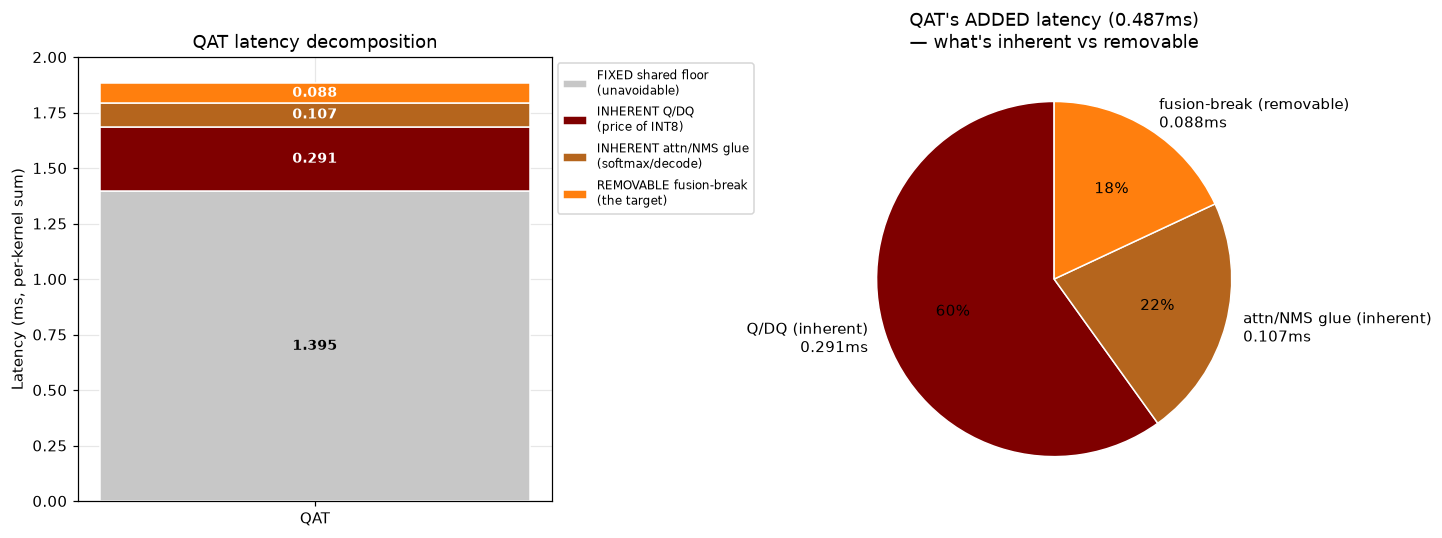

In [30]:
# The headline: QAT's 1.88ms split into fixed / inherent-Q/DQ / inherent-glue / removable
parts = {
    "FIXED shared floor\n(unavoidable)":        (g["fixed_floor"].sum(), C["fixed"]),
    "INHERENT Q/DQ\n(price of INT8)":           (0.2915, C["inherent"]),
    "INHERENT attn/NMS glue\n(softmax/decode)": (0.1072, "#b5651d"),
    "REMOVABLE fusion-break\n(the target)":     (0.0878, C["removable"]),
}
labels = list(parts.keys()); vals = [v[0] for v in parts.values()]; cols = [v[1] for v in parts.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
# stacked bar
bottom=0
for lab,v,c in zip(labels,vals,cols):
    ax1.bar("QAT", v, bottom=bottom, color=c, label=lab, edgecolor="white", linewidth=1)
    ax1.text(0, bottom+v/2, f"{v:.3f}", ha="center", va="center", fontsize=9,
             color="white" if c!=C["fixed"] else "black", fontweight="bold")
    bottom+=v
ax1.set_ylabel("Latency (ms, per-kernel sum)"); ax1.set_title("QAT latency decomposition")
ax1.legend(bbox_to_anchor=(1,1), fontsize=8); ax1.set_ylim(0,2.0)
# pie of just the ADDED part
added = {"Q/DQ (inherent)":0.2915, "attn/NMS glue (inherent)":0.1072, "fusion-break (removable)":0.0878}
ax2.pie(added.values(), labels=[f"{k}\n{v:.3f}ms" for k,v in added.items()],
        colors=[C["inherent"],"#b5651d",C["removable"]], autopct="%1.0f%%", startangle=90,
        wedgeprops={"edgecolor":"white"})
ax2.set_title("QAT's ADDED latency (0.487ms)\n— what's inherent vs removable")
plt.tight_layout(); plt.savefig("chart1_decomposition.png", bbox_inches="tight"); plt.show()

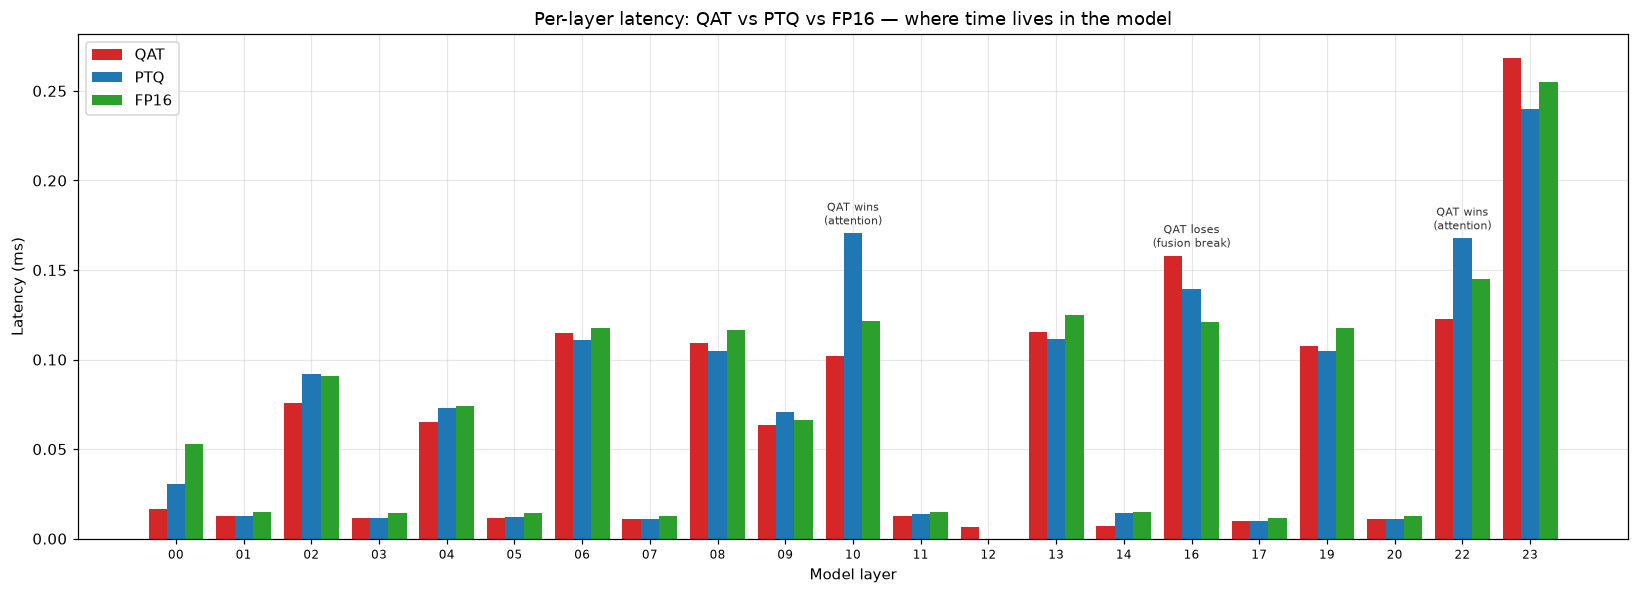

In [31]:
model_layers = [i for i in g.index if i.startswith("model.")]
model_layers = sorted(model_layers, key=lambda x: int(x.split(".")[1]))
x = np.arange(len(model_layers)); w=0.27

fig, ax = plt.subplots(figsize=(15,5.5))
ax.bar(x-w, g.loc[model_layers,"QAT"],  w, label="QAT",  color=C["QAT"])
ax.bar(x,   g.loc[model_layers,"PTQ"],  w, label="PTQ",  color=C["PTQ"])
ax.bar(x+w, g.loc[model_layers,"FP16"], w, label="FP16", color=C["FP16"])
ax.set_xticks(x); ax.set_xticklabels([m.replace("model.","") for m in model_layers], fontsize=8)
ax.set_xlabel("Model layer"); ax.set_ylabel("Latency (ms)")
ax.set_title("Per-layer latency: QAT vs PTQ vs FP16 — where time lives in the model")
ax.legend()
# annotate the attention wins and fusion-break losses
for m,note in [("model.10","QAT wins\n(attention)"),("model.22","QAT wins\n(attention)"),
               ("model.16","QAT loses\n(fusion break)")]:
    i = model_layers.index(m)
    ax.annotate(note, (i, g.loc[m,["QAT","PTQ","FP16"]].max()+0.005),
                ha="center", fontsize=7, color="#333")
plt.tight_layout(); plt.savefig("chart2_perlayer.png", bbox_inches="tight"); plt.show()

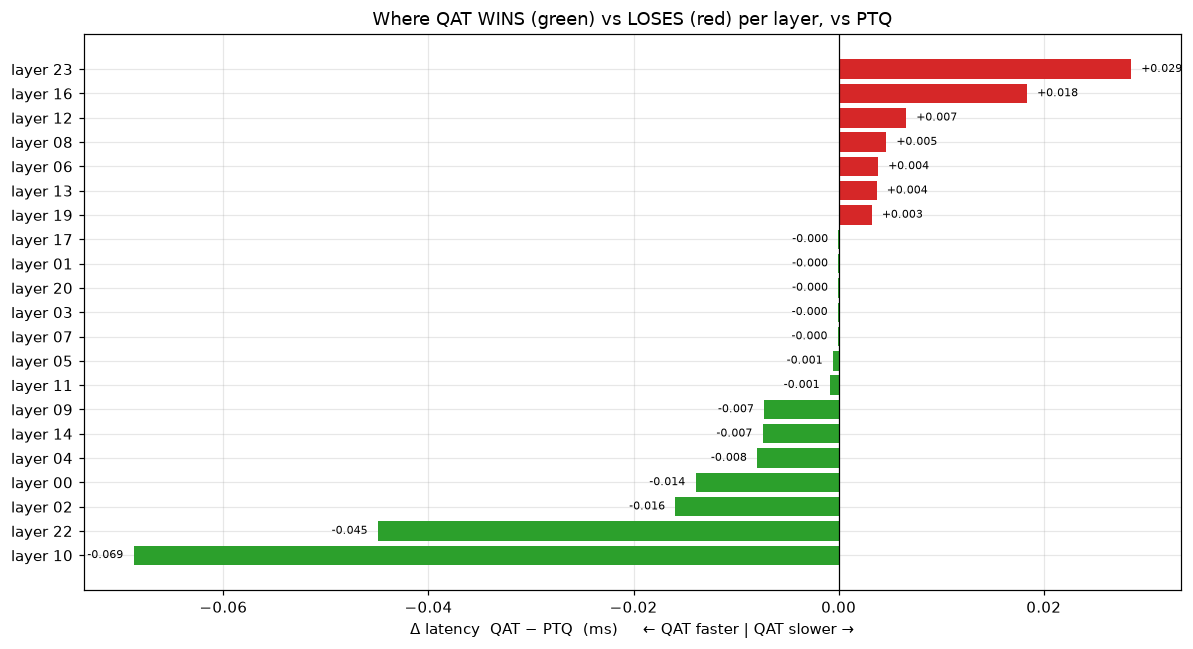

In [32]:
delta = (g.loc[model_layers,"QAT"] - g.loc[model_layers,"PTQ"]).sort_values()
fig, ax = plt.subplots(figsize=(11,6))
colors = ["#2ca02c" if v<0 else "#d62728" for v in delta.values]
ax.barh([m.replace("model.","layer ") for m in delta.index], delta.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Δ latency  QAT − PTQ  (ms)     ← QAT faster | QAT slower →")
ax.set_title("Where QAT WINS (green) vs LOSES (red) per layer, vs PTQ")
for i,(m,v) in enumerate(delta.items()):
    ax.text(v + (0.001 if v>=0 else -0.001), i, f"{v:+.3f}",
            va="center", ha="left" if v>=0 else "right", fontsize=7)
plt.tight_layout(); plt.savefig("chart3_winloss.png", bbox_inches="tight"); plt.show()

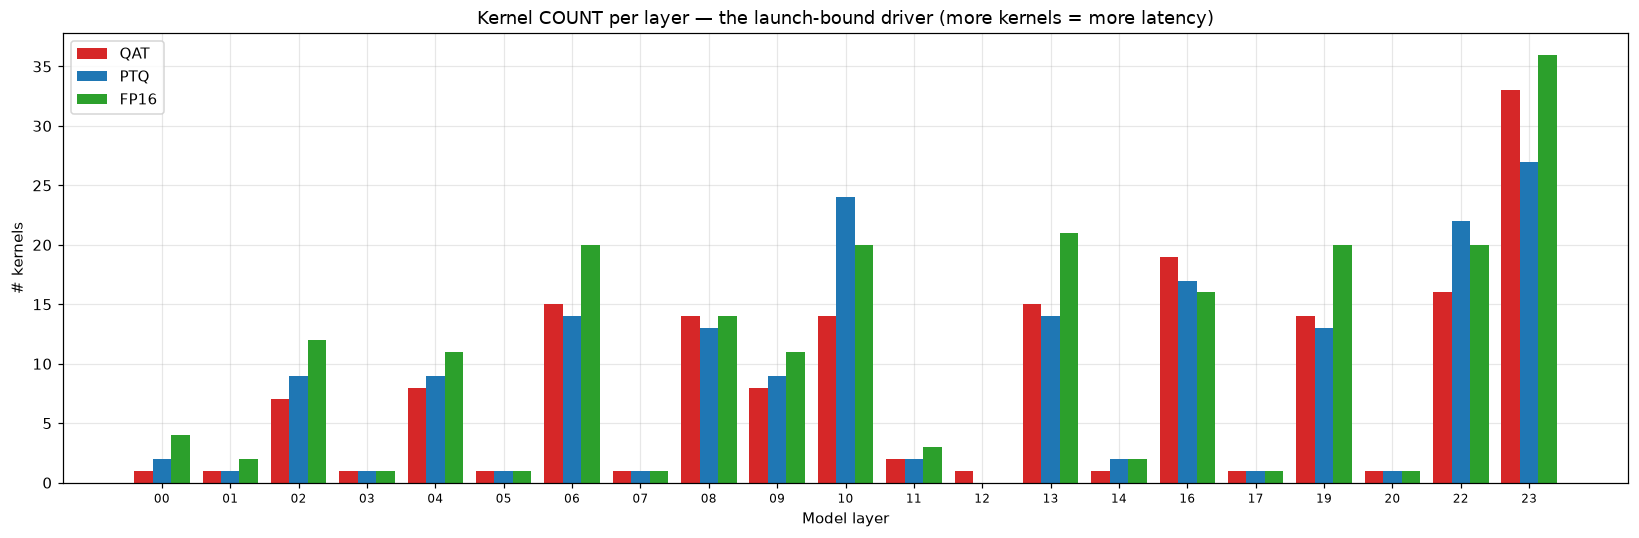

In [33]:
# launch-bound: latency tracks KERNEL COUNT. Show counts side by side.
nq = df_qat.groupby("lg").size(); npt = df_ptq.groupby("lg").size(); nf = df_fp16.groupby("lg").size()
cnt = pd.DataFrame({"QAT":nq,"PTQ":npt,"FP16":nf}).fillna(0).loc[model_layers]
x=np.arange(len(model_layers))
fig, ax = plt.subplots(figsize=(15,5))
ax.bar(x-w, cnt["QAT"], w, label="QAT", color=C["QAT"])
ax.bar(x,   cnt["PTQ"], w, label="PTQ", color=C["PTQ"])
ax.bar(x+w, cnt["FP16"],w, label="FP16",color=C["FP16"])
ax.set_xticks(x); ax.set_xticklabels([m.replace("model.","") for m in model_layers], fontsize=8)
ax.set_xlabel("Model layer"); ax.set_ylabel("# kernels")
ax.set_title("Kernel COUNT per layer — the launch-bound driver (more kernels = more latency)")
ax.legend()
plt.tight_layout(); plt.savefig("chart4_kernelcount.png", bbox_inches="tight"); plt.show()

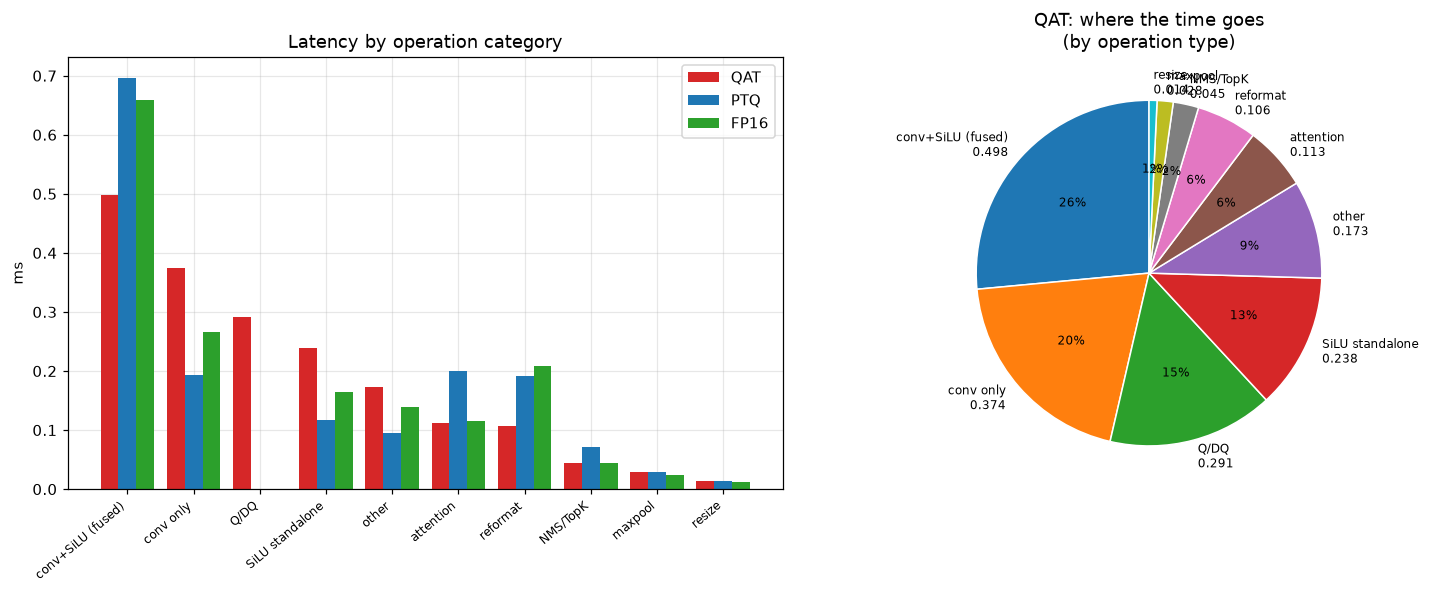

In [34]:
cats = op.index.tolist()
fig, (a1,a2) = plt.subplots(1,2, figsize=(14,5.5))
xc=np.arange(len(cats))
a1.bar(xc-w, op["ms_QAT"], w, label="QAT", color=C["QAT"])
a1.bar(xc,   op["ms_PTQ"], w, label="PTQ", color=C["PTQ"])
a1.bar(xc+w, op["ms_FP16"],w, label="FP16",color=C["FP16"])
a1.set_xticks(xc); a1.set_xticklabels(cats, rotation=40, ha="right", fontsize=8)
a1.set_ylabel("ms"); a1.set_title("Latency by operation category"); a1.legend()
# QAT pie
qvals = op["ms_QAT"][op["ms_QAT"]>0.01]
a2.pie(qvals, labels=[f"{k}\n{v:.3f}" for k,v in qvals.items()], autopct="%1.0f%%",
       startangle=90, wedgeprops={"edgecolor":"white"}, textprops={"fontsize":8})
a2.set_title("QAT: where the time goes\n(by operation type)")
plt.tight_layout(); plt.savefig("chart5_opcategory.png", bbox_inches="tight"); plt.show()

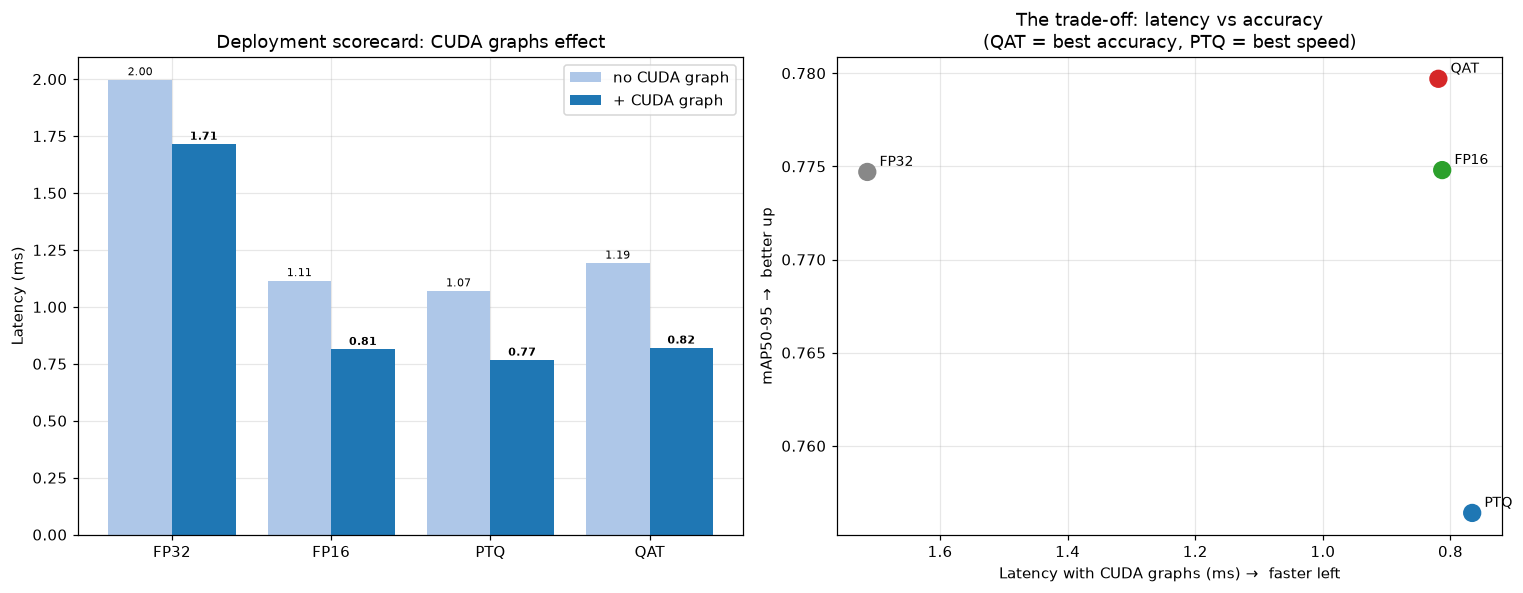

In [35]:
engines = ["FP32","FP16","PTQ","QAT"]
nograph = [1.997, 1.115, 1.070, 1.192]
graph   = [1.714, 0.813, 0.766, 0.819]
maps    = [0.7747, 0.7748, 0.7564, 0.7797]
xe=np.arange(len(engines))

fig, (a1,a2) = plt.subplots(1,2, figsize=(14,5.5))
# grouped bars no-graph vs graph
a1.bar(xe-0.2, nograph, 0.4, label="no CUDA graph", color="#aec7e8")
a1.bar(xe+0.2, graph,   0.4, label="+ CUDA graph",  color="#1f77b4")
for i,(ng,gp) in enumerate(zip(nograph,graph)):
    a1.text(i-0.2, ng+0.02, f"{ng:.2f}", ha="center", fontsize=7)
    a1.text(i+0.2, gp+0.02, f"{gp:.2f}", ha="center", fontsize=7, fontweight="bold")
a1.set_xticks(xe); a1.set_xticklabels(engines); a1.set_ylabel("Latency (ms)")
a1.set_title("Deployment scorecard: CUDA graphs effect"); a1.legend()
# latency vs accuracy scatter (the trade-off)
a2.scatter(graph, maps, s=120, c=[C.get(e,"#888") for e in ["FP32","FP16","PTQ","QAT"]], zorder=3)
for e,gp,mp in zip(engines,graph,maps):
    a2.annotate(e, (gp,mp), textcoords="offset points", xytext=(8,4), fontsize=9)
a2.set_xlabel("Latency with CUDA graphs (ms) →  faster left"); a2.set_ylabel("mAP50-95 →  better up")
a2.set_title("The trade-off: latency vs accuracy\n(QAT = best accuracy, PTQ = best speed)")
a2.invert_xaxis()
plt.tight_layout(); plt.savefig("chart6_scorecard.png", bbox_inches="tight"); plt.show()

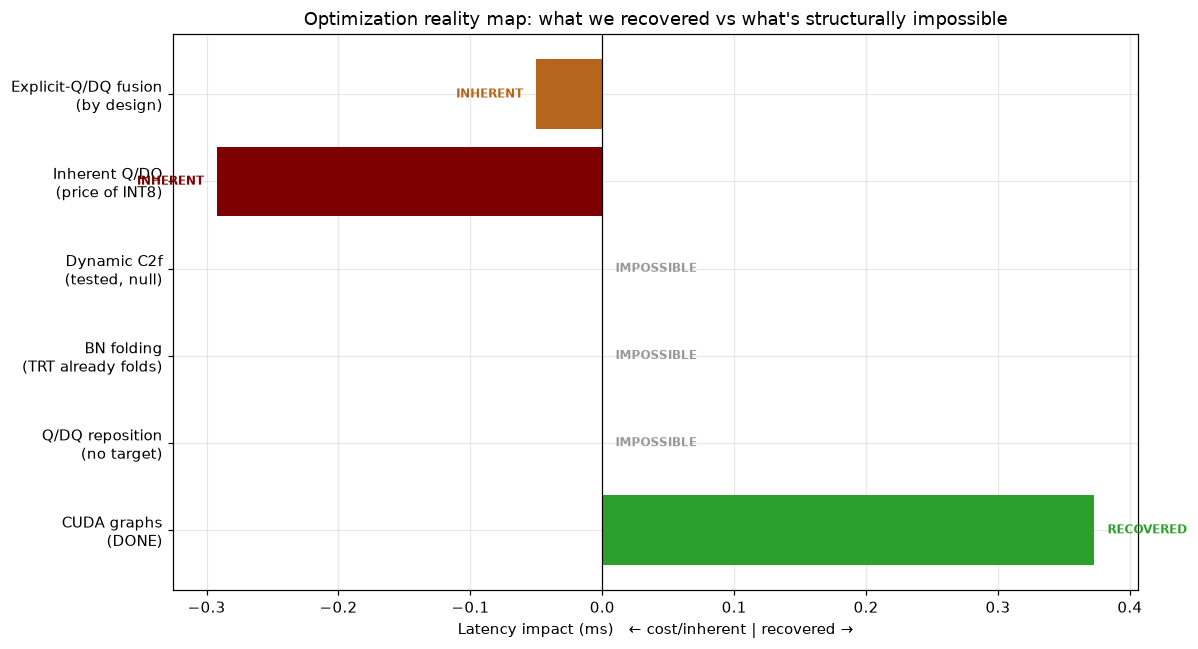

In [36]:
# The story chart: what's recoverable vs structurally impossible
fig, ax = plt.subplots(figsize=(11,6))
categories = [
    ("CUDA graphs\n(DONE)",           0.373, "#2ca02c", "RECOVERED"),
    ("Q/DQ reposition\n(no target)",  0.0,   "#999999", "IMPOSSIBLE"),
    ("BN folding\n(TRT already folds)",0.0,   "#999999", "IMPOSSIBLE"),
    ("Dynamic C2f\n(tested, null)",   0.0,   "#999999", "IMPOSSIBLE"),
    ("Inherent Q/DQ\n(price of INT8)",-0.292,"#7f0000", "INHERENT"),
    ("Explicit-Q/DQ fusion\n(by design)",-0.05,"#b5651d","INHERENT"),
]
names=[c[0] for c in categories]; vals=[c[1] for c in categories]; cols=[c[2] for c in categories]
bars=ax.barh(names, vals, color=cols)
ax.axvline(0,color="black",lw=0.8)
ax.set_xlabel("Latency impact (ms)   ← cost/inherent | recovered →")
ax.set_title("Optimization reality map: what we recovered vs what's structurally impossible")
for i,(n,v,c,tag) in enumerate(categories):
    ax.text(v+(0.01 if v>=0 else -0.01), i, tag, va="center",
            ha="left" if v>=0 else "right", fontsize=8, fontweight="bold", color=c)
plt.tight_layout(); plt.savefig("chart7_reality_map.png", bbox_inches="tight"); plt.show()

In [37]:
# which layers' Q/DQ kernels cost the most?
qdq = df_qat[df_qat["kind"]=="Q/DQ"].copy()
qdq["loc"] = qdq["name"].apply(lambda n:
    (re.search(r"myl(\d+)", n).group(0) if re.search(r"myl(\d+)", n) else "?"))
# map myl-id back to layer if possible, else group by the myl block
print("=== Q/DQ kernels ranked by latency ===")
print(qdq.nlargest(15,"averageMs")[["name","averageMs"]].to_string(index=False))
print(f"\nTotal Q/DQ: {qdq['averageMs'].sum():.4f} ms across {len(qdq)} kernels")
print(f"Mean per Q/DQ kernel: {qdq['averageMs'].mean():.5f} ms")
print(f"Spread: min {qdq['averageMs'].min():.5f} / max {qdq['averageMs'].max():.5f}")

=== Q/DQ kernels ranked by latency ===
                                           name  averageMs
 __myl_MulMinMaxRounCastReplConcReshTran_myl5_0   0.008044
                 __myl_MulMinMaxRounCast_myl0_0   0.007718
                __myl_MulMinMaxRounCast_myl10_0   0.006852
            __myl_CastMulMinMaxRounCast_myl20_0   0.006804
           __myl_CastMulMinMaxRounCast_myl144_0   0.006783
                 __myl_MulMinMaxRounCast_myl8_0   0.006703
            __myl_CastMulMinMaxRounCast_myl26_0   0.006418
       __myl_CastMulMinMaxRounCastResh_myl122_0   0.006352
__myl_MulMinMaxRounCastReshTranReshTran_myl93_0   0.006182
            __myl_MulMinMaxRounCastResh_myl98_0   0.006129
                __myl_MulMinMaxRounCast_myl45_0   0.006127
        __myl_CastMulMinMaxRounCastResh_myl17_0   0.006125
           __myl_CastMulMinMaxRounCast_myl165_0   0.006120
       __myl_CastMulMinMaxRounCastResh_myl127_0   0.006116
           __myl_CastMulMinMaxRounCast_myl116_0   0.006107

Total Q/DQ: 0.29